In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
from wordcloud import WordCloud, STOPWORDS 
from sklearn.feature_extraction.text import CountVectorizer 
import numpy as np 
import re

## EDA

### Load Data & Quick Check

In [2]:
# Load dataset hasil No.1
df = pd.read_csv("hsr_reviews_en.csv")

# Lihat 5 baris pertama
df.head()

,review_text,rating,review_date
0,"I love this game, it's really F2P friendly, an...",5,2025-11-07 19:52:22
1,Child Phainon does not look like Phainon,2,2025-11-07 19:21:22
2,Trash 🗑️🚮 you guys don't care about stelle mai...,1,2025-11-07 19:20:35
3,maybe if this game had a better writer.....,1,2025-11-07 19:07:17
4,50/50 is a complete lie its more like 75/25 on...,1,2025-11-07 18:32:27


Hasil sudah sesuai dengan harapan saat melakukan scrappingan, dan sudah siap untuk di EDA

### Check Tipe Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_text  1000 non-null   object
 1   rating       1000 non-null   int64 
 2   review_date  1000 non-null   object
dtypes: int64(1), object(2)
memory usage: 23.6+ KB


Dataset berisi **1000 review berbahasa inggris**, tipe data juga sudah sesuai dimana *review_text* berbentuk **object**, *rating* berbentuk **integer**, sedangkan *review_date* masih berbentuk **object**, dia masih disimpan sebagai **string**, nanti akan kuubah menjaddi **datetime** untuk kebutuhan EDA

### Check Missing Value

In [4]:
df.isna().sum()

review_text    0
rating         0
review_date    0
dtype: int64

Tidak ada missing value di dataset

### Check Duplicated Value

In [5]:
df.duplicated().sum()

0

Tidak ada review duplikat di dataset

### Distribusi Rating & Contoh Review per Rating

In [6]:
# Distribusi rating (jumlah)
rating_counts = df["rating"].value_counts().sort_index()
rating_counts

rating
1    533
2     81
3     60
4     61
5    265
Name: count, dtype: int64

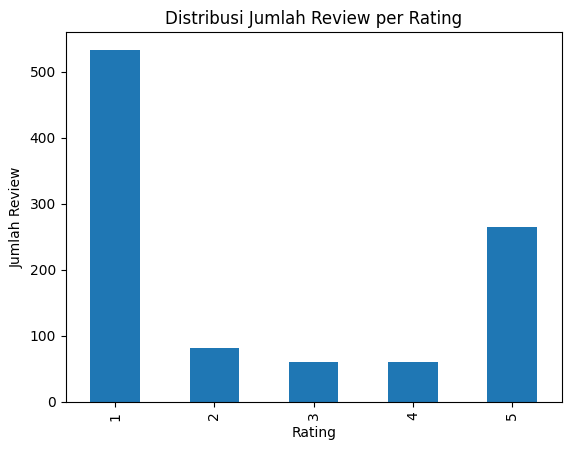

In [7]:
# Plot bar rating
rating_counts.plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Jumlah Review per Rating")
plt.show()

In [8]:
# Proporsi masing-masing rating
rating_ratio = df["rating"].value_counts(normalize=True).sort_index()
rating_ratio

rating
1    0.533
2    0.081
3    0.060
4    0.061
5    0.265
Name: proportion, dtype: float64

Beberapa insight yang ditemukan:
1. **Distribusi rating imbalanced, rating 1 mendominasi dataset.**
   Rating 1 sangat mendominasi dibanding kelas yang lain, diikuti oleh rating 5, sedangkan 2, 3, dan 4 relatif seimbang,  ini masuk akal karena pola review di Google Play secara umum emang seperti itu, di mana review cenderung menumpuk di rating ekstrem (1 dan 5), bukan di tengah.
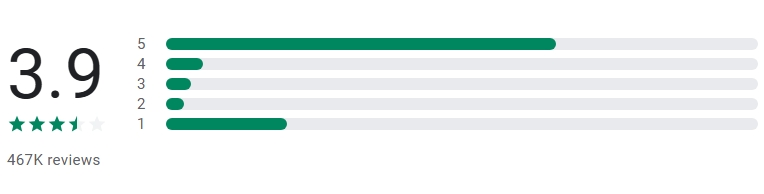
2. **Rating 1 justru menjadi kelas terbanyak.**  
   Menariknya, pada sample dataku(beberapa bulan terakhir) lebih banyak yang mereview **1 daripada 5**, badkan perbeda  hingga 2x lipat. Hal ini mengindikasikan bahwa pada periode review yang di-scrape, banyak pemain yang mengekspresikan ketidakpuasan dalam game, nanti akan aku cari tahu kenapa kira-kira sejalan dengan EDA ini berjalan.
3. **Pendapat pemain cenderung terpolarisasi.**
   Rating tengah (2–4) relatif sedikit dan seimbang, pola ini menunjukkan bahwa pemain cenderung memberikan penilaian yang ekstrem: **sangat tidak puas (1)** atau **sangat puas (5)**, bukan rating main aman aja di tengah tengah.

--- 

Implikasi untuk model, karena target sangat **imbalance**, banyak algoritma machine learning standar akan cenderung belajar lebih baik di kelas mayoritas (1 dan 5) dan mengabaikan kelas minoritas (2, 3, 4). Ini perlu ditangani di tahap berikutnya, misalnya dengan **resampling (SMOTE/SMOTETomek)** yang akan kuterapkan di no 7.

### Contoh review per rating 

In [9]:
for r in sorted(df["rating"].unique()):
    print(f"\n=== Contoh review rating {r} bintang ===")
    sample = df[df["rating"] == r].sample(min(5, (df["rating"] == r).sum()), random_state=501)
    for i, text in enumerate(sample["review_text"], 1):
        print(f"{i}. {text}\n")


=== Contoh review rating 1 bintang ===
1. Game has no real content, power creep is insane and developers genuinely do not care about the community. It's supose to be a story game but the story is garbage too, they go through characters way to fast,without actually giving them proper developement because then need to sell new units.

2. Came back for Cyrene update, events are boring, not excited to do the new main quest and new challenge. I regret coming back

3. Genuinely horrendous experience. Play the game for your favorite character, build them, watch them fade into obscurity and obsoletion less than 1 month later, replaced by a newer character. The greed of the developers of this game is so immense that HSR can barely even be called a game. Skippable story, dialogue, and battles, in order to optimise and incentivize spending. The absolute final nail in the coffin is Cyrene, unplayable before 6 copies, with a $300 skin that does nothing.

4. I really like the game, and I reached eq

### Sekilas contoh review:
#### Rating 1
- **Nada umum:** sangat negatif, kecewa berat.
- **Tema utama:** 
  - powercreep membuat karakter lama terasa tidak relevan.
  - developer dianggap terlalu fokus jual karakter baru (Cyrene) dan skin mahal tapi karakternya dibuat tidak kompetitif
  - progress story dan endgame terasa lama karena musuh terlalu kuat / butuh gacha karakter baru.

#### Rating 2
- **Nada umum:** masih negatif, tapi mereka masih mengakui game ini pernah/masih bagus.
- **Tema utama:**
  - powercreep + HP inflation(boss yang hitpontnya berkali kali lipat dibanding update sebelumnya).
  - karakter lama cepat tidak relevan dan sistem pity/gacha dianggap tidak mwmbantu.
  - developer dinilai makin kesini makin **greedy** dan tidak mendengar komunitas.
#### Rating 3
- **Nada umum:** mixed feelings, suka gamenya, tapi terganggu dengan perkembangan game akhir-akhir ini.
- **Tema utama:**
  - apresiasi terhadap karakter, lore, dan scenery.
  - namun ada masalah teknis (device/graphics issue), tekanan untuk spend, powercreep, dan kurangnya event.
#### Rating 4
- **Nada umum:** positif, keluhan hanya sedikit.
- **Tema utama:**
  - karakter dan story dinilai bagus, fitur baru (misalnya story skip) membantu pengalaman bermain,
  - masih ada keluhan powercreep, HP inflation, atau rasa game mulai **cash grab**
#### Rating 5
- **Nada umum:** sangat positif dan emosional.
- **Tema utama:**
  - apresiasi untuk update dan dedikasi developer
  - story dan cutscene dianggap awesome/beautiful
  - karakter dan pengalaman bermain secara umum sangat memuaskan.
  - jarang ada komentar negatif
#### Ringkasan
- Rating rendah (1–2): review panjang dan detail, fokus pada **keluhan mendasar**  
  (power creep, HP inflation, monetisasi yang greedy, cara developer menangani karakter baru).
- Rating tengah (3): kombinasi antara apresiasi dan kritik, pemain masih menikmati game,
  tapi cukup terganggu isu tertentu sehingga hanya memberi nilai di tengah tengah.
- Rating tinggi (4–5): didominasi oleh **pujian** untuk karakter, story, visual, dan
  update, di rating 4 masih ada sedikit kritik, sedangkan rating 5 hampir murni
  ekspresi suka/puas.

### Distribusi Panjang Review

In [10]:
# Panjang review (char dan word)
df["len_char"] = df["review_text"].astype(str).str.len()
df["len_word"] = df["review_text"].astype(str).str.split().str.len()

df[["len_char", "len_word"]].describe()

,len_char,len_word
count,1000.000000,1000.000000
mean,180.342000,33.022000
std,159.757208,28.988616
min,3.000000,1.000000
25%,44.750000,9.000000
50%,121.500000,22.000000
75%,291.000000,53.000000
max,500.000000,100.000000


Mayoritas review pendek, tetapi ada juga beberapa review yang **panjang dan detail**, terlihat distribusi panjang teks yang **right-skewed** (banyak yang pendek, beberapa sangat panjang), sangat wajar untuk data review user.

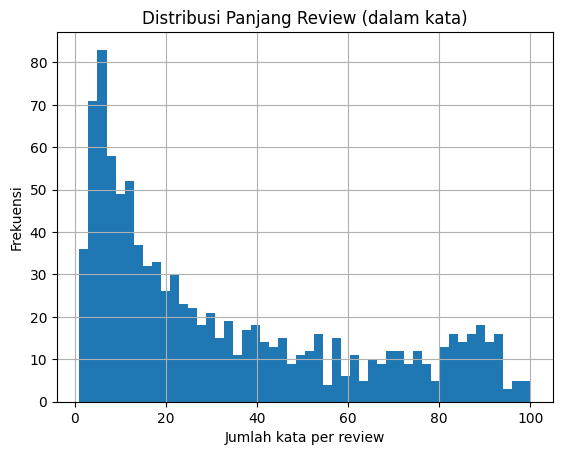

In [11]:
# Histogram panjang review (dalam kata)
df["len_word"].hist(bins=50)
plt.xlabel("Jumlah kata per review")
plt.ylabel("Frekuensi")
plt.title("Distribusi Panjang Review (dalam kata)")
plt.show()

Histogram menunjukkan bahwa mayoritas review memiliki **panjang yang pendek**, konsisten dengan hasil tabel tadi:

---
Puncaknya berada di kiri mungkin sekitar **5–10 kata per review**, ini berarti banyak pemain menulis komentar singkat (1–2 kalimat). Semakin panjang review (di atas ~40–50 kata), frekuensinya makin sedikit.
Hanya ada sedikit review yang sangat panjang (mendekati 100 kata), menunjukkan distribusi yang **right-skewed**.



### Kata Dominan per Rating (tabel)

In [12]:
# Vectorizer global
vectorizer = CountVectorizer(
    stop_words="english",  # buang kata umum bahasa Inggris (the, and, is, dll.) untuk analisa kata dominan
    min_df=5               # hanya simpan kata yang muncul minimal 5 kali di seluruh dataset
)

X = vectorizer.fit_transform(df["review_text"].astype(str)) # matriks (1553 x N) berisi jumlah kemunculan tiap kata untuk tiap review.
vocab = np.array(vectorizer.get_feature_names_out()) # array daftar kata (fitur) yang digunakan.

def get_top_words_for_rating(rating_value, top_n=15):
    mask = (df["rating"] == rating_value).values # pilih baris dengan rating tertentu(1-5)
    counts = np.asarray(X[mask].sum(axis=0)).ravel() # jumlahkan frekuensi kata hanya untuk rating tsb
    top_idx = counts.argsort()[::-1][:top_n] # ambil indeks kata dengan frekuensi terbesar (top 15)
    return pd.DataFrame({
        "word": vocab[top_idx], # kata yang ketemu
        "freq": counts[top_idx] # frekuensinya
    })

top_words_rating = {}
for r in sorted(df["rating"].unique()):
    top_df = get_top_words_for_rating(r, top_n=15)
    top_words_rating[r] = top_df
    print(f"\n=== Top 15 kata untuk rating {r} bintang ===")
    display(top_df)


=== Top 15 kata untuk rating 1 bintang ===


,word,freq
0,game,325
1,cyrene,195
2,character,141
3,just,124
4,characters,122
5,story,77
6,new,77
7,like,76
8,kit,64
9,greedy,60



=== Top 15 kata untuk rating 2 bintang ===


,word,freq
0,game,92
1,characters,33
2,like,25
3,good,24
4,just,23
5,cyrene,18
6,play,18
7,ve,17
8,really,16
9,hoyo,15



=== Top 15 kata untuk rating 3 bintang ===


,word,freq
0,game,65
1,characters,28
2,story,20
3,good,17
4,just,15
5,new,15
6,like,15
7,character,14
8,lot,13
9,powercreep,13



=== Top 15 kata untuk rating 4 bintang ===


,word,freq
0,game,78
1,good,26
2,story,22
3,characters,20
4,like,20
5,really,16
6,just,13
7,don,12
8,love,12
9,great,11



=== Top 15 kata untuk rating 5 bintang ===


,word,freq
0,game,217
1,love,94
2,characters,79
3,story,72
4,good,57
5,like,46
6,really,44
7,just,36
8,play,35
9,fun,33


### Analisis Top-15 Kata Dominan per Rating

Dengan menghitung frekuensi kata per rating dengan `CountVectorizer`, ini adalah kata yang paling sering muncul di setiap kelas rating.

#### Rating 1 (Sangat Tidak Puas)

**Kata dominan:**  
`game, cyrene, character, characters, story, new, like, just, bad, good, powercreep, greedy, time, money, kit`

Cirinya:
- Muncul kata bernada negatif seperti **bad** dan **greedy**.
- Istilah **powercreep** ini cukup menonjol, mengindikasikan keluhan soal **balancing karakter** dan dampak karakter baru yang membuat karakter lama kurang relevan.
- **Cyrene** (karakter baru) sering muncul bersamaan dengan keluhan power creep, masuk akal karena banyak pemain merasa karakter baru membuat karakter lama terasa tidak relevan.

**Kesimpulan rating 1:** review disini didominasi keluhan tentang **balance, monetisasi, dan karakter baru yang terlalu kuat**, sehingga banyak pemain merasa game menjadi tidak adil dan menjadi lebih **greedy**.

---

#### Rating 2 (Tidak Puas)

**Kata dominan:**  
`game, characters, like, just, good, play, story, really, powercreep, character, power, love, cyrene, creep, playing`

Cirinya:
- Kata positif masih muncul: **good**, **love**, **like**, yang artinya pemain **masih mengapresiasi** beberapa aspek game (karakter, story, gameplay).
- Kata seperti **powercreep**, **creep**, dan **power** menandakan adanya masalah serius yang mengganggu (misalnya balancing, power creep, atau desain endgame).
- Rating 2 ini kebanyakan masih suka dengan gamenya, tapi banyak masalah terlalu parah sehingga mereka kasih rating yang rendaj.

**Kesimpulan rating rendah (1–2):**  
Di dua kelas ini banyak muncul kata seperti **bad**, **greedy**,
**powercreep/creep”**, serta nama karakter baru (**Cyrene**). Hal ini
menunjukan banyak keluhan kuat terhadap **balancing karakter, sistem gacha &
monetisasi, serta konten endgame**. Pemain di kelas ini levih fokus pada
kekurangan yang mereka anggap merusak pengalaman bermain mereka.

---

#### Rating 3 (Netral / Campuran)

**Kata dominan:**  
`game, characters, story, good, new, like, character, just, really, love, play, powercreep, star, fun, don`

Cirinya:
- Banyak kata positif: **good**, **love**, **fun**, **story**, **characters**.
- Kata **powercreep** masih muncul di Top-15, menunjukkan bahwa masalah balancing di game ini masih serius.
- Ini sesuai dengan rating 3 yang merepresentasikan **mixed feelings**: *gamenya bagus, tapi ada beberapa hal yang cukup mengganggu*.

**Kesimpulan rating 3:** 
Review di kelas ini berisi campuraan antara pujian dan kritik, pemain masih menikmati game, tetapi tidak memberi nilai tinggi karena beberapa isu (terutama power creep dan balancing).

---

#### Rating 4 (Puas)

**Kata dominan:**  
`game, good, story, characters, like, really, just, love, great, fun, new, character, stars, events, gacha`

Cirinya:
- Kata bernada positif mendominasi seperti: **good**, **great**, **love**, **fun**.
- Kata **events** dan **gacha** mulai muncul, tetapi konteksnya lebih ke komentar/kritik detail, bukan keluhan besar yang membuat mereka menurunkan rating drastis.
- Pemain di segmen ini umumnya puas, hanya memiliki beberapa catatan kecil yang menggangu mereka.

**Kesimpulan rating 4:** mayoritas review berisi **apresiasi** terhadap
karakter, cerita, dan gameplay, dan kritik yang lebih halus terhadap event
atau sistem gacha.

---

#### Rating 5 (Sangat Puas)

**Kata dominan:**  
`game, love, characters, story, good, like, really, just, best, play, character, fun, amazing, games, star`

Cirinya:
- Kata sangat positif mendominasi: **love**, **best**, **amazing**, **good**, **fun**.
- Fokus pujian terutama pada **karakter**, **story**, dan pengalaman bermain mereka secara keseluruhan.
- Hampir tidak ada kata bernada negatif yang muncul di Top-15 untuk rating 5.

**Kesimpulan rating tinggi (4–5):**  
Segmen pemain ini memberikan rating tinggi karena **pengalaman menyenangkan dan keunggulan game** (karakter, cerita, visual, gamepay). Kritik teknis seperti powercreep atau gacha jauh lebih jarang muncul. Review 5 bintang umumnya berupa pujian singkat atau cerita pengalaman positif yang sangat antusias.

---

Polanya review ini mendukung temuan bahwa **perbedaan rating banyak dipengaruhi oleh seberapa besar pemain merasa terganggu dengan masalah balancing / powercreep dan monetisasi**, dibandingkan dengan apresiasi terhadap karakter dan cerita yang secara umum dianggap kuat, serta menjelaskan mengapa akhir akhir ini reviewnya sangat jelek, disini juga ditemukan beberapa kata yang terlalu umum di game ini, contohnya **game**, **nama developer**, dan  **game-game hoyoverse yang lain**, disini akan kutambahkan ke custom stopwords


### Wordcloud per Rating

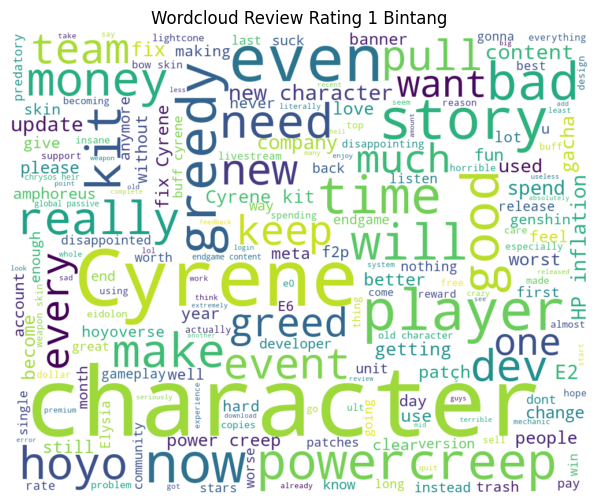

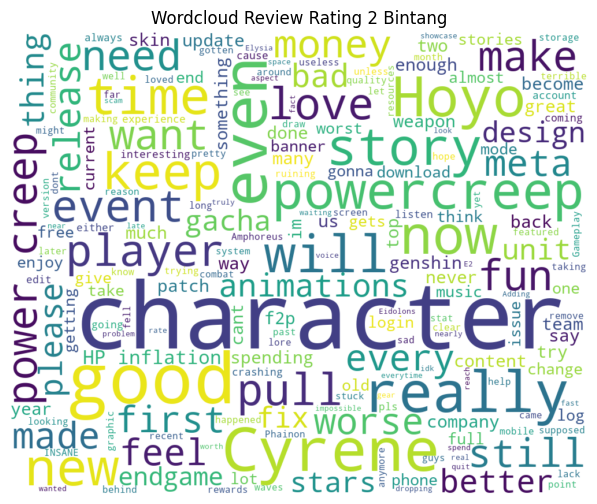

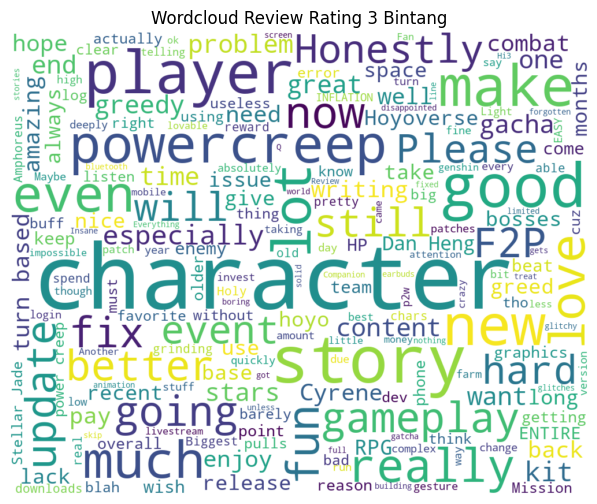

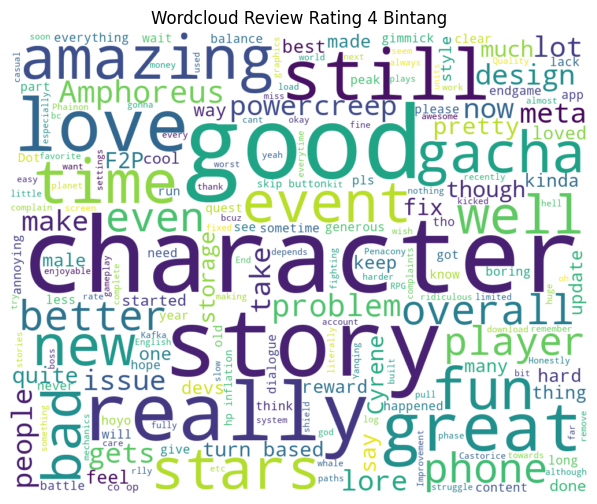

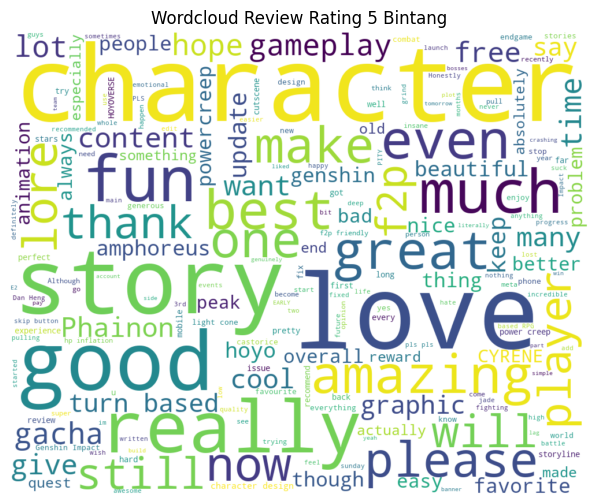

In [13]:
# (berisi kata-kata umum bahasa Inggris seperti: the, and, is, dll)
stopwords = set(STOPWORDS)

# ambahan stopword khusus untuk domain game ini
custom_stopwords = {
    "game", "games", "play", "played", "playing",
    "honkai", "star", "rail", "hsr" 
}
# Gabungkan stopword bawaan + stopword custom menjadi satu set
stopwords = stopwords.union(custom_stopwords)
# Ambil daftar rating yang ada di dataset, lalu di-sort (misal: [1, 2, 3, 4, 5])
ratings_sorted = sorted(df["rating"].unique())

# Loop untuk membuat wordcloud per rating (1 sampai 5)
for r in ratings_sorted:
    # Gabungkan semua review_text dengan rating r menjadi satu string besar
    text = " ".join(df.loc[df["rating"] == r, "review_text"].astype(str))
    
    wc = WordCloud(
        width=1000,
        height=800,
        background_color="white",
        stopwords=stopwords,
        min_font_size=10
    ).generate(text) # generate wordcloud dari text gabungan review
    
    plt.figure(figsize=(8, 6))
    plt.imshow(wc, interpolation="bilinear") # render image wordcloud
    plt.axis("off") # sembunyikan axis (x,y)
    plt.title(f"Wordcloud Review Rating {r} Bintang") # judul sesuai rating
    plt.show()

### Wordcloud per Rating
Wordcloud per rating menguatkan temuan dari tabel top-words:
- **Rating 1–2**: kata negatif seperti **powercreep, greedy, gacha, money** dan nama karakter baru **Cyrene** sangat dominan bisa diliat dari banyaknya keluhan soal balancing, power creep, dan monetisasi.
- **Rating 3**: campuran kata positif (**good, fun, love**) dan negatif (**powercreep, problem, issue**)  menunjukan **mixed feelings**.
- **Rating 4–5**: didominasi kata sangat positif seperti **love, good, great, fun, amazing, best, thank** menunjukan review fokus pada pengalaman menyenangkan, kritik lebih dikit.

Dari pola ini wajar kalau beberapa kata dijadikan **domain stopword**, misalnya:
- Nama game / developer: `honkai`, `star`, `rail`, `hsr`, `hoyo`, `hoyoverse`, `mihoyo`, `genshin`
- Kata sangat umum di konteks ini: `game`, `games`, `play`, `playing`, `player`, `players`

### Kata Non-Standar & Ringkasan

In [14]:
# Frekuensi global semua kata
global_counts = np.asarray(X.sum(axis=0)).ravel()
freq_df = pd.DataFrame({
    "word": vocab,
    "freq": global_counts
}).sort_values("freq", ascending=False)

freq_df.head(30)


,word,freq
208,game,777
71,characters,282
105,cyrene,230
282,just,211
513,story,204
70,character,204
308,like,182
224,good,180
334,love,147
443,really,130


ada beberapa tambahan domain stopword yang ingin kutambahkan seperti **ve** yang meripakan artefak dari I've atau we've, lalu **time** yang merupakan kata umum, **content** juga konteks umum, **players** juga sangat generik

In [15]:
# Fungsi untuk menandai kata yang dianggap "tidak standar"
def is_nonstandard(word):
    if re.search(r"[0-9]", word):   # mengandung angka
        return True
    if re.search(r"[^a-z]", word):  # selain huruf a-z
        return True
    if len(word) == 1 and word not in {"a", "i"}: # Jika kata hanya 1 huruf, dan bukan "a" atau "i", anggap tidak standar
        return True
    return False

# Tambahkan kolom baru 'nonstandard_flag' ke freq_df
freq_df["nonstandard_flag"] = freq_df["word"].apply(is_nonstandard)

# Filter hanya kata-kata yang ditandai non-standar dan punya frekuensi cukup besar (freq >= 20), supaya fokus ke yang sering muncul
nonstandard_df = freq_df[(freq_df["nonstandard_flag"]) & (freq_df["freq"] >= 20)]
nonstandard_df.head(30)


,word,freq,nonstandard_flag
173,f2p,70,True
4,300,40,True
5,50,36,True
142,e2,34,True
144,e6,21,True


f2p mengacu pada istilah free_to_play dalam HSR, dan sepertinya angka disini uang dalam dollar yang dikeluarkan permain itu, misalnya **10, 50, 300** , lalu istilah e2 dan e6 yang mengacu ke istilah **eidolon level 2 / 6**, istilah spesifik di HSR, aku akan standarkan jadi **eilodon nanti**, overall kata-kata yang tidak sesuai standar bahasa ini adalah istilah slang dalam game ini, dan mungkin bisa distandarisasi di preprocessingnya

### Analisa Tanggal Awal dan Akhir Review Dibuat

In [16]:
# Ubah tipe data ke datetime sesuai degan temuan sebelumnya
df["review_date"] = pd.to_datetime(df["review_date"])

# tanggal paling awal & paling akhir
print("Tanggal review paling awal :", df["review_date"].min())
print("Tanggal review paling akhir:", df["review_date"].max())


Tanggal review paling awal : 2025-10-05 07:45:20
Tanggal review paling akhir: 2025-11-07 19:52:22


Sesuai dengan cara scrapping data kita yaitu sort from newest

### Analisa Jumlah Review Per Bulan

Jumlah review per bulan:
review_year_month
2025-10    662
2025-11    338
Freq: M, Name: count, dtype: int64


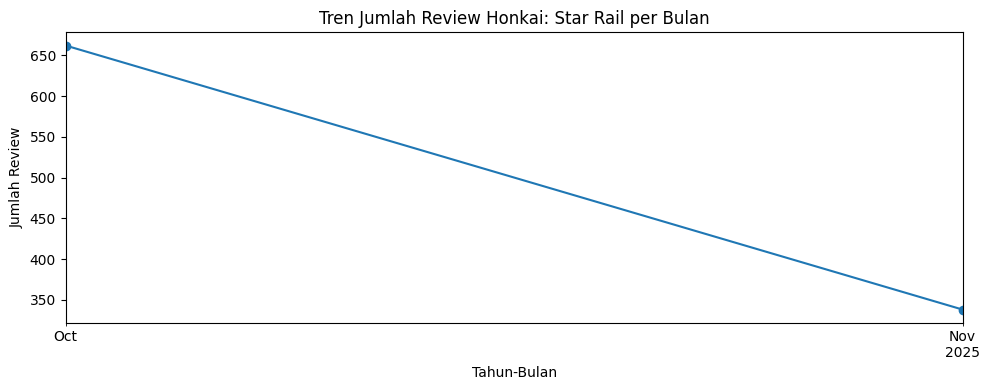

In [17]:
# Tahun dan tahun-bulan
df["review_year"] = df["review_date"].dt.year
df["review_year_month"] = df["review_date"].dt.to_period("M")

# Jumlah review per bulan
month_counts = df["review_year_month"].value_counts().sort_index()
print("Jumlah review per bulan:")
print(month_counts)

month_counts.plot(kind="line", marker="o", figsize=(10, 4))
plt.xlabel("Tahun-Bulan")
plt.ylabel("Jumlah Review")
plt.title("Tren Jumlah Review Honkai: Star Rail per Bulan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Hasil sudah sesuai dengan yang diharapkan terlihat bahwa Oktober banyak, karena dimulai dari tanggal 5 Oktober sampai akhir Oktober, lalu di November masih sedikit karena baru sampai tanggal 7 November

## Preprocessing

In [18]:
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
from sklearn.model_selection import train_test_split

In [19]:
cols_to_drop = [c for c in ["review_date", "review_year", "review_year_month"] if c in df.columns]
df = df.drop(columns=cols_to_drop)

Disini kolom **review_date**, **review_year**, **review_year_month**, sudah tidak terpakai lagi, sudah dipakai saat EDA, aku drop aja karena fokusku untuk memprediksi rating hanya dari isi teks review, dan menghapus kolom yang tidak relevan membantu **menyederhanakan dataset**, mengurangi potensi kebingungan, dan membuat pipeline preprocessing lebih bersih dan terfokus pada teks.

### Siapkan stopword umum + domain game

In [20]:
# Stopword bahasa Inggris standar dari NLTK
base_stopwords = set(stopwords.words("english"))

# Kata-kata negasi penting yang tidak boleh jadi stopword supaya makna kalimat (positif/negatif) tidak terbalik
negation_words = {
    "no", "nor", "not", "never"
}

# Hilangkan negasi dari daftar stopword
base_stopwords = base_stopwords.difference(negation_words)

# Stopword khusus domain Honkai: Star Rail (dari hasil EDA)
domain_stopwords = {
    # nama game / dev / universe
    "honkai", "star", "rail", "hsr", "hoyo", "hoyoverse", "mihoyo", "genshin", "zzz"

    # kata sangat umum di konteks ini (kurang informatif sebagai pembeda sentimen)
    "game", "games", "play", "played", "playing",
    "player", "players",
    "content", "time",

    # artefak tokenisasi / noise yang sering muncul
    "ve",   # dari "we've"
}

# Gabungkan stopword umum + domain
all_stopwords = base_stopwords.union(domain_stopwords)


Disini aku membuang stopword yang umum dalam bahasa inggris karena tidak banyak membantu untuk pemodelan (misalnya *the, is, at, on,* dll), mereka kurang informatif dan hanya menambah dimensi, lalu aku juga menjaga kata negasi **no, nor, not, never** agar tidak dibuang karena angat penting untuk makna kalimat (misalnya good vs not good), beberapa kata itu jadi aku exclude dari **stopword** 

---
Dari hasil EDA, ada banyak kata yang sering muncil tapi **kurang informatid** untuk membedakan rating, contohnya
- Nama game/dev: `honkai, star, rail, hsr, hoyo, hoyoverse, mihoyo, genshin, zzz`
- Kata yang sangar umum untuk konteks ini: `game, games, play, played, playing, player, players, content, time`
- Noise tokenisasi: `ve` (sisa dari we've)
Kata - kata ini aku masukan ke domain_stopword, lalu aku gabungkan stopword inggris dasar(tanpa negasi) ditambah stopword khusus game **Honkai Star Rail**




### Kamus sederhana untuk istilah non-standar

In [21]:
# Kamus normalisasi istilah yang sering muncul di review
normalization_dict = {
    # istilah domain
    "f2p": "free_to_play",
    "p2w": "pay_to_win",
    "hp": "health",
    "atk": "attack",
    "def": "defense",
    "spd": "speed",
    "e0": "eidolon_0",
    "e1": "eidolon_1",
    "e2": "eidolon_2",
    "e3": "eidolon_3",
    "e4": "eidolon_4",
    "e5": "eidolon_5",
    "e6": "eidolon_6",
    "c0": "eidolon_0",
    "c1": "eidolon_1",
    "c2": "eidolon_2",
    "c3": "eidolon_3",
    "c4": "eidolon_4",
    "c5": "eidolon_5",
    "c6": "eidolon_6",
    "bis": "best_in_slot",
    "lc": "light_cone",
    # typo yang aku ketemu sekilas
    "bqck": "back",
    "orher": "other",
    "fav": "favorite",
    "charaters": "characters",
    "powercreeping": "powercreep",
    
    
    # normalisasi negasi / contraction -> satu bentuk konsisten "not"
    "dont": "not",
    "don't": "not",
    "cant": "not",
    "can't": "not",
    "wont": "not",
    "won't": "not",
    "didnt": "not",
    "didn't": "not",
    "isnt": "not",
    "isn't": "not",
    "doesnt": "not",
    "doesn't": "not",
}

Disini aku menulis **slang word** di **Honkai Star Rail** dan mencoba untuk menyeragamkannya, jika dibiarkan apa adanya, model akan menganggap mereka sebagai kata berbeda padahal artinya sama. Dengan kamus ini, semua singkatan dinormalisasi ke bentuk yang lebih konsisten seperti **free_to_play** sehingga
**makna tetap terjaga** dan **variasi token berkurang**

### Helper: mapping POS ke WordNet & normalisasi istilah

In [22]:
def get_wordnet_pos(treebank_tag):
    """
    Konversi POS tag NLTK (NN, VB, JJ, RB, dst.)
    ke POS WordNet (NOUN, VERB, ADJ, ADV).
    Kalau tidak dikenali, return None.
    """
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("N"):
        return wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    else:
        return None

lemmatizer = WordNetLemmatizer()

Sebelum lemmatization, aku menyiapkan helper untuk **menghubungkan POS tag NLTK
dengan POS versi WordNet**. Tujuannya supaya lemmatizer tahu suatu kata itu noun/verb/adjective/adverb, sehingga bentuk dasarnya bisa
diambil dengan lebih akurat.

### Fungsi preprocessing utama

In [23]:
def preprocess_text(text):
    """
    Preprocessing rule-based (tidak .fit() ke data):
    - lowercasing
    - hapus URL & HTML
    - normalisasi istilah/typo (f2p, p2w, dont, dst.)
    - buang karakter non-alfanumerik berat (emoji, simbol)
    - tokenization
    - stopword removal + filter token tidak informatif
    - lemmatization dengan POS
    Return: list token bersih (sudah di-lemmatize)
    """
    # 1. Pastikan string & lowercase
    text = str(text).lower()

    # 2. Hapus URL dan link
    text = re.sub(r"http\S+|www\S+", " ", text)

    # 3. Hapus HTML tag jika ada
    text = re.sub(r"<.*?>", " ", text)

    # 4. Normalisasi istilah/typo dari kamus
    for src, tgt in normalization_dict.items():
        text = re.sub(rf"\b{re.escape(src)}\b", tgt, text)

    # 5. Hapus karakter yang bukan huruf a-z, ANGKA 0-9, underscore, atau spasi
    #    (emoji, simbol, punctuation akan dibuang di sini)
    text = re.sub(r"[^a-z0-9_\s]", " ", text)

    # 6. Hilangkan spasi berulang
    text = re.sub(r"\s+", " ", text).strip()

    # 7. Tokenization
    tokens = word_tokenize(text)

    # 8. Stopword removal + filtering token yang tidak informatif
    filtered_tokens = []
    for tok in tokens:
        # buang stopword umum + domain
        if tok in all_stopwords:
            continue

        if len(tok) == 1:
            continue

        filtered_tokens.append(tok)

    # 9. Lemmatization dengan menggunakan POS tag
    if not filtered_tokens:
        return []

    pos_tags = pos_tag(filtered_tokens, lang="eng")
    lemmas = []
    for tok, tag in pos_tags:
        wn_pos = get_wordnet_pos(tag)
        if wn_pos:
            lemmas.append(lemmatizer.lemmatize(tok, pos=wn_pos))
        else:
            lemmas.append(lemmatizer.lemmatize(tok))

    return lemmas


Disini ada beberapa step preprocess yang kumasukan seperti:
- **Cleansing Dasar**:
    - lowercase semua string supaya misal `Game`, `GAME`, dan `game` diperlakukan sama
    - hapus url/link karena pola seperti `http...` atau `www...` tidak informatif untuk rating.
    - hapus HTML tag seperti `<br>`, `<div>`, dst. agar tidak ikut menjadi token.
- **Normalisasi istilah / typo berbasis kamus**
    - Istilah domain seperti misal **f2p** menjadi **free_to_play**, supaya lebih **makns tetap terjaga** dan **variasi token berkurang**
    - Typo yang kutemukan sekilas seperti **bqck dan other** dibenarkan
- Hapus karakter non huruf, angka, huruf, dan spasi seperti **emoji**, **punctuation**, dan **simbol**
    - Angka **sengaja dipertahankan**, karena informasi seperti **300 dollar**, **10 pulls**,bisa relevan untuk menggambarkan pengalaman dan sentimen pemain. 
- Rapikan spasi berulang dengan strip()
- Tokenisasi untuk memecah list token menjadi kata misalnya: `"not free_to_play anymore"` -> `["not", "free_to_play", "anymore"]`.
- **Stopword Removal**
    - **bahasa Inggris standar** (NLTK)
    - buang satu huruf
    - ditambah **stopword khusus domain Honkai: Star Rail**, misalnya:
       `honkai, star, rail, hsr, hoyo, hoyoverse, mihoyo, genshin, zzz,
        game, games, play, played`, dll.
- **Lemmatization berdasarkan POS tag**
    - Token yang sudah difilter di-POS-tag dengan `pos_tag` (NN, VB, JJ, RB, dst), lalu dikonversi ke format WordNet dengan fungsi `get_wordnet_pos`(`NOUN`, `VERB`, `ADJ`, `ADV`)
    - Jika POS tidak dikenali, lemmatization dilakukan dengan pengaturan
     default 

### Train test split di raw text

In [24]:
# Fitur teks utama
X_raw = df["review_text"]
# Label rating
y     = df["rating"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_raw))
print("Test size :", len(X_test_raw))

Train size: 800
Test size : 200


Kenapa `train_test_split` dilakukan sekarang?

- **Memisahkan data train dan data test dari sekarang**  
  Supaya semua langkah yang *belajar dari data* (TF-IDF, Word2Vec, SMOTE, model ML) hanya melihat **data train**, bukan data test untuk mencegah **data leakage**.

- **`X_raw` dan `y` masih dalam bentuk yang paling murni**  
  Di sini kita pakai teks asli (`review_text`) dan label (`rating`). Setelah split, barulah setiap subset diproses dipreprocessing dengan aturan yang sama.

- **`stratify=y` menjaga distribusi label**  
  Proporsi rating (1–5) di train dan test dibuat mirip dengan distribusi aslinya, jadi evaluasi model nanti lebih representatif.

### Preprocessing Diterapkan ke Train & Test

In [25]:
X_train_tokens = X_train_raw.apply(preprocess_text)
X_test_tokens  = X_test_raw.apply(preprocess_text)

# Buat versi string untuk TF-IDF
X_train_clean = X_train_tokens.apply(lambda toks: " ".join(toks))
X_test_clean  = X_test_tokens.apply(lambda toks: " ".join(toks))

# Cek tidak ada baris kosong total
mask_train_empty = X_train_clean.str.strip() == ""
mask_test_empty  = X_test_clean.str.strip() == ""

print("Empty train after preprocess:", mask_train_empty.sum())
print("Empty test  after preprocess:", mask_test_empty.sum())

Empty train after preprocess: 0
Empty test  after preprocess: 1


Setelah preprocessing, 1 sampel di test set menjadi kosong (semua token terhapus). Sampel ini tetap dipertahankan, dalam representasi TF-IDF dan Word2Vec, sampel tersebut dipetakan ke vektor nol.

## Text Representation

#### Alasan Pemilihan TF-IDF dan Word2Vec

Soal meminta **2 jenis text representation**:
1. **Metode yang nilai vektornya merepresentasikan seberapa penting kata** dalam suatu data sample.  
2. **Metode yang vektornya direpresentasikan oleh kata-kata di sekitarnya**,   yang dilatih dengan **model ANN**, di mana input adalah kata dan target adalah kata-kata di konteksnya.

Dari deskprisi soal ini, aku pilih:

- **TF-IDF** untuk metode pertama  karena TF-IDF (Term Frequency–Inverse Document Frequency) memang dirancang untuk
  mengukur **seberapa penting** sebuah kata/bigram di satu dokumen dibandingkan dokumen lain.

- **Word2Vec (skip-gram)** untuk metode kedua karena Word2Vec skip-gram adalah **model ANN sederhana** yang dilatih dengan:
    - input = satu kata,
    - target = kata-kata di sekitarnya,  
    sehingga menghasilkan vektor kata yang merepresentasikan **konteks di sekeliling kata**.

Jadi, pemilihan TF-IDF dan Word2Vec di sini langsung mengikuti dua deskripsi dari soal:
- **pentingnya kata di dokumen**  TF-IDF,  jadi TF itu seberapa sering kata itu muncul di review tersebut dan IDF seberapa jarang kata itu muncul di seluruh kumpulan review.
- **vektor dari kata di sekitarnya, dilatih dengan ANN input–konteks** itu adalah Word2Vec (skip-gram) -> skipgram inilah yang menebak dari satu kata, dia menebak kata-kata di sekitarnya.

### TF-IDF (Fit di train, Transform Test)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
# TF-IDF: bobot pentingnya kata/bigram di setiap review
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigram + bigram
    min_df=5, # hanya kata/bigram yang muncul di ≥ 5 dokumen
    max_df=0.9 # buang kata yang muncul di > 90% dokumen
)

X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf  = tfidf.transform(X_test_clean)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test  shape:", X_test_tfidf.shape)

TF-IDF train shape: (800, 669)
TF-IDF test  shape: (200, 669)


### TF-IDF Vectorizer

- **Tujuan:** Mengubah teks (`X_train_clean`, `X_test_clean`) menjadi fitur numerik berbasis **TF-IDF**  
  (seberapa penting sebuah kata/bigram di sebuah review dibanding seluruh corpus).

- **Konfiggurasi penting:**
  - `ngram_range=(1, 2)` : pakai **unigram** (kata tunggal) dan **bigram** (contoh: `powercreep`, `gacha lightcone`).
  - `min_df=5` : hanya simpan kata/bigram yang muncul **di ≥ 5 dokumen**  
    untuk buang kata yang terlalu jarang / noise.
  - `max_df=0.9` : buang kata/bigram yang muncul di **> 90% dokumen**  
    untuk kata terlalu umum (kurang informatif) tidak dijadikan fitur.

- **Kenapa `fit` di train saja?**  :

  Ini lebih ke supaya model belaajar **vocab dan IDF** dari data train saja untuk **mencegah leakage data**, test di transform saja untuk mendapatkan **ruang fitur yang sama** tanpa mengajari vectorizer.

- **Hasil:**
  - `TF-IDF train shape: (800, 669)`  : 800 review train, masing-masing direpresentasikan oleh 669 fitur (kata/bigram).
  - `TF-IDF test shape: (200, 669)`  : 200 review test, jumlah fitur sama 669

### Word2Vec (Fit di train aja)

In [27]:
from gensim.models import Word2Vec

In [28]:
w2v_dim = 100 # dimensi embedding

# Word2Vec dilatih hanya dari kalimat train
sentences_train = X_train_tokens.tolist()

w2v_model = Word2Vec(
    sentences=sentences_train,
    vector_size=w2v_dim,
    window=5,
    min_count=3,
    sg=1, # skipgram
    workers=4,
    epochs=20,
    seed=42
)

print("Vocab size :", len(w2v_model.wv))
print("Embed dim  :", w2v_model.vector_size)

Vocab size : 806
Embed dim  : 100


### Word2Vec (Skip-gram) untuk Representasi Kata

- **Tujuan:** Belajar **embedding kata** dari review HSR di data **train** aja, lalu nanti dipakai untuk membuat vektor dokumen (dengan rata-rata embedding tiap kata).

- **Konfigurasi utama:**
  - `vector_size = 100` : setiap kata diwakili oleh vektor berdimensi **100**  
    (cukup kaya naamun tetaplah ringan untuk ML klasik).
  - `window = 5` : model melihat sampai **5 kata di kiri & kanan** sebagai konteks.
  - `min_count = 3` : hanya kata yang muncul **≥ 3 kali** di data train yang dimasukkan ke vocab  
    : kata yang sangar jarang dibuang karena cenderung menjadi noisy.
  - `sg = 1` : pakai **Skip-gram** (lebih bagus menangkap representasi kata yang jarang, cocok untuk vocab domain).
  - `epochs = 20` : data diulang 20 kali saat training untuk menstabilkan embedding.
  - `sentences = X_train_tokens` : **hanya token dari train** yang dipakai belajar embedding  
    untuk mencegah data leakage dari test.

- **Hasil:**
  - `Vocab size : 806`  : ada **806 kata unik** di data train yang lolos `min_count=3` dan dipelajari embedding-nya.
  - `Embed dim : 100`  : setiap kata di vocab tersebut direpresentasikan sebagai vektor sepanjang 100 angka.


In [29]:
def review_to_vec(tokens, model, dim):
    """
    Ubah list token menjadi satu vektor dokumen
    dengan merata-ratakan embedding semua kata yg ada di vocab.
    Jika semua token OOV maka vektor nol.
    """
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if not vecs:
        return np.zeros(dim)
    return np.mean(vecs, axis=0)

# Embedding untuk train
X_train_embed = np.vstack([
    review_to_vec(tokens, w2v_model, w2v_dim)
    for tokens in X_train_tokens
])

# Embedding untuk test
X_test_embed = np.vstack([
    review_to_vec(tokens, w2v_model, w2v_dim)
    for tokens in X_test_tokens
])

print("Embedding train shape:", X_train_embed.shape)
print("Embedding test  shape:", X_test_embed.shape)

Embedding train shape: (800, 100)
Embedding test  shape: (200, 100)


### Rata-rata Word2Vec :

- `review_to_vec(tokens, w2v_model, w2v_dim)`  
  - Ambil embedding Word2Vec untuk setiap token yang ada di vocab (`model.wv`).  
  - Jika tidak ada kata yang dikenal maka kembalikan vektor nol berukuran `dim`.  
  - Jika ada kembalikan **rata-rata** semua embedding kata (mean pooling).

- Penerapan ke seluruh data:
  - `X_train_embed`: hasil `np.vstack(...)`  **800 × 100**  : 800 review train, masing-masing vektor 100 dimensi.
  - `X_test_embed`: hasil `np.vstack(...)` **200 × 100**  : 200 review test, dimensi fitur sama.

- Tujuan: mengubah setiap review menjadi **satu vektor numerik** berbasis Word2Vec, siap dipakai model ML klasik.


### Simpan semua representasi dalam satu dict

In [30]:
representations = {
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
    "Word2Vec": (X_train_embed, X_test_embed),
}

### Cek bentuk & beberapa elemen dari setiap representasi

In [31]:
for name, (Xtr, Xte) in representations.items():
    print(f"\n=== {name} ===")
    print("Train shape:", Xtr.shape)
    print("Test  shape:", Xte.shape)

    # contoh isi baris pertama
    if name == "TF-IDF":
        # TF-IDF itu sparse, jadi kita ubah dulu ke dense 1 baris
        row_dense = Xtr[0].toarray()[0]
        # ambil indeks fitur yang nilainya non-zero
        nz_idx = row_dense.nonzero()[0]

        print("Non-zero features in first train sample (up to 10):")
        for i in nz_idx[:10]:
            print(f"  {tfidf.get_feature_names_out()[i]} -> {row_dense[i]:.4f}")

    elif name == "Word2Vec":
        # Word2Vec sudah numpy array dense
        print("First train vector (first 10 dims):")
        print(Xtr[0][:10])


=== TF-IDF ===
Train shape: (800, 669)
Test  shape: (200, 669)
Non-zero features in first train sample (up to 10):
  300 -> 0.1277
  character -> 0.0652
  come -> 0.2393
  consider -> 0.1674
  current -> 0.1750
  do -> 0.1539
  either -> 0.1674
  enough -> 0.1375
  event -> 0.3569
  find -> 0.1797

=== Word2Vec ===
Train shape: (800, 100)
Test  shape: (200, 100)
First train vector (first 10 dims):
[ 0.15505984  0.11528258  0.02584014  0.01543422 -0.10562581  0.15751883
  0.26237011  0.22629216 -0.09744506 -0.06115166]


### Isi `representations`

**TF-IDF**
- Shape: train `(800, 669)`, test `(200, 669)`. Tiap angka = bobot TF-IDF kata/bigram di dokumen itu.

**Word2Vec**
- Shape: train `(800, 100)`, test `(200, 100)`.
  Satu vektor 100 dimensi yang merangkum makna review (rata-rata embedding kata).


## Model

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

### Kenapa akhirnya Terpilih Logistic Regression dan Linear SVM?

1. **Cocok untuk data teks high-dimensional**  
   TF-IDF sendiri menghasilkan ratusan fitur (669), dan Word2Vec menghasilkan vektor dense.  
   Kedua model ml ini adalah **model linear**, jadi menurutku cocok untuk:
   - fitur **banyak dan sparse** (TF-IDF)  
   - fitur **dense berukuran sedang** (Word2Vec).

2. **Baseline yang kuat di text classification**  
   - **Logistic Regression** sering dijadikan baseline standr:
     - bisa menghasilkan **probabilitas per kelas**, sehingga prediksi lebih mudah dijelaskan.
   - **Linear SVM** terkenal **kuat secara margin** di data teks:
     - sering memberi performa sangat baik di ruang fitur besar,
     - meskipun tidak mengeluarkan probabilitas secara langsung.

3. **Mendukung penanganan imbalance secara sederhana**  
   Keduanya mendukung `class_weight="balanced"` dan pengaturan **regularisasi `C`**,  
   sehingga bisa:
   - mengatasi ketidakseimbangan label tanpa mengubah data yang mentah
   - bisa melakukan tuning sederhana tapi bermakna.

Alasan lainnya karena (**time constraint**), jujur:)), banyak ujian yang masih harus dipikirkan dan butuh model yang cepet
   


### Fungsi Evaluasi

In [33]:
def eval_model(rep_name, model_name, model, Xtr, ytr, Xte, yte, print_report=True):
    """Helper supaya nggak copy–paste metric berulang.
    Meng-train model, prediksi di test, lalu hitung metric utama.
    """
    # Prediksi label untuk data test
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    # Hitung accuracy dan macro precision/recall/F1
    acc = accuracy_score(yte, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        yte, y_pred, average="macro"
    )

    # Prediksi label untuk data test
    if print_report:
        print(f"\n=== {rep_name} + {model_name} (baseline) ===")
        print(f"Accuracy       : {acc:.4f}")
        print(f"Macro Precision: {prec:.4f}")
        print(f"Macro Recall   : {rec:.4f}")
        print(f"Macro F1       : {f1:.4f}")
        print(classification_report(yte, y_pred))
        
    # Kembalikan hasil dalam bentuk dict supaya bisa dikumpulkan jadi DataFrame (biar mirip kayak yang
    # ada di soal (tabel))
    return {
        "Text Representation": rep_name,
        "Algorithm": model_name,
        "Accuracy": acc,
        "Macro Precision": prec,
        "Macro Recall": rec,
        "Macro F1": f1,
    }

Fungsi ini aku buat sebagai **helper** supaya tidak perlu berulang kali menulis kode evaluasi untuk
setiap kombinasi:
- text representation (TF-IDF / Word2Vec),
- algoritma model (LogReg / SVM),
- dan setting (baseline / ROS) -> No 7

---

Dia akan melakukan model training di `Xtr`,`ytr`, lalu prediksi data di test `Xte` dengan 4 metric utama, lalu dia akan print lengkap ke **classification report**, lalu, setelah itu mengembalikan hasil dalam bentuk dictionary sehingga semua hasil dari berbagai kombinasi **(LogRes & SVM)** bisa digabung menjadi satu DataFrame sebagai tabel ringkasan (sesuai format tabel yang diminta di soal).

4 metric yang digunakan:
- **Accuracy** : Proporsi prediksi model yang tepat dibanding total data test.
  Kenapa dipakai?
  - Ini metrik yang paling intuitif, gampang dijelaskan ke orang awam.
  - Bagus sebagai gambaran umum performa model, namunnnn
      - Kalau datasetnya imbalence seperti di kasus ini, model bisa curang karena nebak yang di kelas mayoritas aja, accuracy bisa aja terlihat tinggi tapi kelas minoritas diabain.

- **Precision (Macro Precision)** :
Precision untuk satu kelas, misalnya dari semua review yang diprefiksi oleh model kita menjadi **rating 1**, berapa si yang bener-bener rating 1?
    Kenapa dipakai?
    - untuk tau seberapa bersih prediksi di kelas itu, apakah model sering salah tuduh(**false positive**)
    - Biar ga terlalu jago memprediksi di kelas yang mayoritas tapi kalau di rating minoritas
  Semua kelas punya hak suara yang sama, kelas yang datanya sedikit tidak tenggelam oleh kelas mayoritas.

- **Recall (Macro Recall)** :
Recall untuk satu kelas, misalnya dari semua review yang sebenarnya rating 1, berapa banyak yang berhasil ditangkap model sebagai rating 1?
    Kenapa dipakai?
    - Kalau kita peduli kelas minoritas(misalnya 2-4) di kasus ini,
    - Fokusnya lebih ke seberapa banyak yang **kecolongan** (**false negative**)
  Kalau macro recall rendah, berarti ada kelas yang sering tidak terdeteksi.

- **F1 (Macro F1)**: F1 untuk satu kelas adalah harmonic mean antara precision dan recall. F1 akan tinggi  precision dan recall dua-duanya lumayan, kalau salah satu acnur, F1 ikut turun.
    Kenapa dipakai?
    - Data rating imbalance, jadi kita mau seadil adilnya ke semua kelas bukan buat yang mayoritas aja
 
Intinya, model terbaik bukan cuma akurasinya tinggi, tapi juga Macro F1-nya bagus dan tidak mengorbankan kelas tertentu.

---


### Model Baseline

In [34]:
baseline_models = {
    # Logistic Regression setting default baseline
    "LogReg": LogisticRegression(
        max_iter=5000, # iter banyak biar konvergen
        n_jobs=-1, # pakai semua core untuk percepat training
        multi_class="auto", 
        C=1.0, # nilai regulerisasi default
        class_weight=None, # belim pakai penanganan imbalance
    ),
    # Linear Support Vector Machine setting default baseline
    "LinearSVM": LinearSVC(
        C=1.0, # nilai regulerisasi default
        class_weight=None, # belum pakai penanganan imbalance
    ),
}

baseline_results = [] # untuk nyimpan hasil evaluasi semua kombinasi

# Loop semua kombinasi: (TF-IDF / Word2Vec) × (LogReg / LinearSVM)
for rep_name, (Xtr, Xte) in representations.items():
    for model_name, model in baseline_models.items():
        # Train + evaluasi model dengan fungsi helper yang sudah dibuat
        res = eval_model(rep_name, model_name, model, Xtr, y_train, Xte, y_test)
        baseline_results.append(res)  # simpan hasil ke list

# Ubah list of dict jadi DataFrame(permintaan soal)
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df

C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\anaconda


=== TF-IDF + LogReg (baseline) ===
Accuracy       : 0.6950
Macro Precision: 0.2754
Macro Recall   : 0.3284
Macro F1       : 0.2981
              precision    recall  f1-score   support

           1       0.71      0.96      0.82       107
           2       0.00      0.00      0.00        16
           3       0.00      0.00      0.00        12
           4       0.00      0.00      0.00        12
           5       0.67      0.68      0.67        53

    accuracy                           0.69       200
   macro avg       0.28      0.33      0.30       200
weighted avg       0.56      0.69      0.62       200


=== TF-IDF + LinearSVM (baseline) ===
Accuracy       : 0.6250
Macro Precision: 0.3324
Macro Recall   : 0.3295
Macro F1       : 0.3197
              precision    recall  f1-score   support

           1       0.72      0.80      0.76       107
           2       0.11      0.06      0.08        16
           3       0.25      0.08      0.12        12
           4       0.00    

C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

,Text Representation,Algorithm,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF,LogReg,0.695,0.275402,0.328372,0.298072
1,TF-IDF,LinearSVM,0.625,0.332385,0.329537,0.319708
2,Word2Vec,LogReg,0.630,0.240170,0.296456,0.265126
3,Word2Vec,LinearSVM,0.655,0.252034,0.311515,0.278474


### Hasil Baseline Model (sebelum penanganan imbalance / tuning)

Set up baseline:

- 2 text representation:
  - **TF-IDF**
  - **Word2Vec (mean embedding)**
- 2 model:
  - **Logistic Regression**
  - **Linear SVM (LinearSVC)**

---

### Interpretasi

1. **Model cenderung main aman (curang) karena hanya merepresentasikan kelas mayoritas (rating 1 dan 5)**  
   Dari `classification_report`, terlihat:
   - Rating **1** dan **5** punya precision/recall yang tinggi, tapi....
   - Rating **2, 3, 4** sering memiliki:
     - precision = 0.00  
     - recall = 0.00  
    kecuali di **TF-IDF + LinearSVM**, artinya model **tidak pernah memprediksi** kelas-kelas minoritas ini, dan hanya merepresentasikan kelas major, masuk akal karena blm dimasukan pengangan imbalance sama sekali.

2. **Accuracy lumayan, tapi Macro F1 rendah**  
   - Contoh: **TF-IDF + LogReg**
     - Accuracy = **0.695**
     - Macro F1 = **0.298**
   - Ini menunjukkan:
     - model sering benar untuk kelas uang mayoritas (1 & 5), tapi...
     - **sangat buruk** untuk kelas 2,3,4, sehingga Macro F1 jelek.

   Jadi untuk data yang **imbalanced**(seperti dalam kasus ini dimana rating 2-4 minor), kalau hanya melihat accuracy hasilnya itu bisa dibilang **menipu**, macro F1 lebih membantu menggambarkan performa rata-rata di semua kelas.

3. **Perbandingan TF-IDF vs Word2Vec (baseline)**

   - Secara umum, **TF-IDF** memberikan Macro F1 yang **sedikit lebih baik** daripada Word2Vec di baseline.
   - Contoh Macro F1:
     - TF-IDF + LinearSVM  : **0.3197** (terbaik di baseline)
     - TF-IDF + LogReg     : 0.2981
     - Word2Vec + LinearSVM : 0.2785
     - Word2Vec + LogReg    : 0.2651

   Ini konsisten dengan teori:
   - untuk model linear klasik seperti ini, **TF-IDF** sering lebih stabil dibanding Word2Vec yang dilatih di korpus kecil.

4. **Perbandingan LogReg vs LinearSVM (baseline)**

   - Di TF-IDF:
     - LogReg : Memiliki accuracy yang tertinggi (**0.695**), namun Macro F1 sedikit lebih rendah.
     - LinearSVM : akurasii sedikit turun (**0.625**), tapi Macro Precision & Macro F1 sedikit lebih baik.
   - Di Word2Vec:
     - LinearSVM sedikit lebih unggul sedikit dibanding LogReg di semua macro metric.

   Jadi di baseline:
   - Kalau hanya melihat **Accuracy** : TF-IDF + LogReg tampil paling tinggi, tapi itu menipu.
   - Kalau fokus ke **rata-rata performa di semua kelas (Macro F1)** :  **TF-IDF + LinearSVM** jadi kandidat baseline terbaik, inilah yang perlu coba digali.

---

### Kesimpulan baseline
- Semua model baseline **masih dominan ke kelas mayoritas** (rating 1 dan 5).
- Macro F1 yang rendah menunjukkan perlunya:
  - penanganan **class imbalance**, dan
  - **hyperparameter tuning** (misalnya `C`, `class_weight`).
- Dari baseline, kombinasi yang relatif paling bagus:
  - **TF-IDF + LinearSVM** (Macro F1 tertinggi),
  - dan **TF-IDF + LogReg** kalau dilihat dari Accuracy saja.

### Tuned Model (dengan menggunakan Grid Search CV)

In [35]:
tuned_settings = {
    # Hyperparameter Tuning LogRes
    "LogReg": (
        LogisticRegression(
            max_iter=5000,       # iter banyak biar konvergen
            n_jobs=-1,           # pakai semua core untuk percepat training
            multi_class="auto"  
        ),
        {
            # Hyperparameter yang akan di-grid search:
            "C": [0.01, 0.1, 1, 10],          # kekuatan regularisasi (semakin kecil semakin kuat regulasinya)
            "class_weight": [None, "balanced"],  # opsi penanganan imbalance
        },
    ),
    "LinearSVM": (
        LinearSVC(),
        {
            "C": [0.01, 0.1, 1, 10],          # kekuatan regularisasi (semakin kecil semakin kuat regulasinya)
            "class_weight": [None, "balanced"], # opsi penanganan imbalance
        },
    ),
}

tuned_results = []  # untuk menyimpan hasil semua kombinasi (rep × model)

# Loop untuk semua kombinasi text representation × model
for rep_name, (Xtr, Xte) in representations.items():
    for model_name, (base_model, param_grid) in tuned_settings.items():
        print(f"\n==============================")
        print(f"{rep_name} + {model_name} (GridSearch)")
        print("==============================")

        # GridSearchCV untuk cari kombinasi hyperparameter terbaik
        grid = GridSearchCV(
            estimator=base_model,   # model dasar (LogReg / LinearSVM)
            param_grid=param_grid,  # daftar hypertuning param yang dipakai
            scoring="f1_macro",     # pakai macro-F1 sebagai skor utama (karena data imblance)
            cv=5,                   # 5-fold cross validation
            n_jobs=-1,              # paralel di semua core
            verbose=1,              # print progress
        )
        grid.fit(Xtr, y_train)      # fit grid search di data train 

        best_model = grid.best_estimator_    # ambil model dengan kombinasi hyperparameter terbaik
        print("Best params:", grid.best_params_)

        # Evaluasi model terbaik di data test
        y_pred = best_model.predict(Xte)

        acc = accuracy_score(y_test, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="macro"
        )

        # Print hasil evaluasi di test
        print(f"Accuracy       : {acc:.4f}")
        print(f"Macro Precision: {prec:.4f}")
        print(f"Macro Recall   : {rec:.4f}")
        print(f"Macro F1       : {f1:.4f}")
        print(classification_report(y_test, y_pred))

        # Simpan hasil ke list sebagai satu baris
        tuned_results.append({
            "Text Representation": rep_name,
            "Algorithm": model_name,
            "Best Params": grid.best_params_,   # kombinasi C + class_weight terbaik
            "Accuracy": acc,
            "Macro Precision": prec,
            "Macro Recall": rec,
            "Macro F1": f1,
        })

# Ubah list of dict jadi DataFrame(permintaan soal)
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df



TF-IDF + LogReg (GridSearch)
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'C': 1, 'class_weight': 'balanced'}
Accuracy       : 0.5400
Macro Precision: 0.3730
Macro Recall   : 0.4044
Macro F1       : 0.3777
              precision    recall  f1-score   support

           1       0.79      0.61      0.69       107
           2       0.10      0.12      0.11        16
           3       0.15      0.25      0.19        12
           4       0.23      0.42      0.29        12
           5       0.60      0.62      0.61        53

    accuracy                           0.54       200
   macro avg       0.37      0.40      0.38       200
weighted avg       0.61      0.54      0.57       200


TF-IDF + LinearSVM (GridSearch)
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'C': 1, 'class_weight': 'balanced'}
Accuracy       : 0.5750
Macro Precision: 0.3603
Macro Recall   : 0.3700
Macro F1       : 0.3628
              precision    recall  f1-score   support

           1       0.79      0.67      0.73       107
           2     

C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'C': 0.1, 'class_weight': 'balanced'}
Accuracy       : 0.4800
Macro Precision: 0.3472
Macro Recall   : 0.3679
Macro F1       : 0.3414
              precision    recall  f1-score   support

           1       0.81      0.52      0.64       107
           2       0.12      0.25      0.17        16
           3       0.18      0.33      0.24        12
           4       0.12      0.17      0.14        12
           5       0.50      0.57      0.53        53

    accuracy                           0.48       200
   macro avg       0.35      0.37      0.34       200
weighted avg       0.59      0.48      0.52       200


Word2Vec + LinearSVM (GridSearch)
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'C': 10, 'class_weight': 'balanced'}
Accuracy       : 0.6000
Macro Precision: 0.2959
Macro Recall   : 0.3096
Macro F1       : 0.2984
              precision    recall  f1-score   support

           1       0.75      0.77      0.76       107
           2

,Text Representation,Algorithm,Best Params,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF,LogReg,"{'C': 1, 'class_weight': 'balanced'}",0.540,0.373039,0.404357,0.377734
1,TF-IDF,LinearSVM,"{'C': 1, 'class_weight': 'balanced'}",0.575,0.360322,0.370035,0.362835
2,Word2Vec,LogReg,"{'C': 0.1, 'class_weight': 'balanced'}",0.480,0.347212,0.367880,0.341446
3,Word2Vec,LinearSVM,"{'C': 10, 'class_weight': 'balanced'}",0.600,0.295913,0.309560,0.298444


### Hasil Hyperparameter Tuning (GridSearchCV)

Set up tuning:

- 2 text representation:
  - **TF-IDF**
  - **Word2Vec (mean embedding)**
- 2 model:
  - **Logistic Regression** 
  - **Linear SVM (LinearSVC)**
- Hyperparameter yang di-tuning:
  - `C ∈ {0.01, 0.1, 1, 10}` -> Semakin kecil, semakin kuat efek regulasinya, tapi dampaknya model lebih mudah overfit, sebaliknya semakin besar semakin lemah efek regulasinya dengan resiko underfit, tapi bisa juga lebih stabil di test
  - `class_weight ∈ {None, "balanced"}` -> memberi bobot yang lebih besar pada kelas yang minor, memperbesar kemunhkinan kelas minoritas bisa terprediksi
- Skor yang dioptimasi di GridSearch: **`f1_macro`** -> sesuai dengan tujuan kita untuk membuat kelas minor lebih direpresentadikan


### Interpretasi
1. **Tuning + `class_weight='balanced'` membuat model lebih melek pada kelas minoritas**
   Semua kombinasi terbaik  **memilih `class_weight='balanced'`**,  baik untuk TF-IDF atau Word2Vec.
   Dampaknya:
   - Akurasinya **menurun** jika dibanding baseline (contohnya TF-IDF+LogReg dari **0.695 -> 0.540**),tapi  **Macro Precision, Macro Recall, dan Macro F1 naik cukup signifikan**, terutama di kelas minoritas (rating 2,3,4) -> sesuai target

   Contoh TF-IDF + LogReg:
   - **Baseline**:
     - Acc = 0.695, Macro F1 = 0.2981  
     - Kelas 2–4 nyaris tidak pernah terprediksi.
   - **Setelah tuning (`C=1`, `class_weight='balanced'`)**:
     - Acc = 0.540 nya turun tapi,
     - Macro F1 = 0.3777 (naik cukup besar),
     - Kelas 2–4 mulai punya precision/recall > 0 (model mulai bisa memprediksi minor class).

   Jadi, tuning ini memang mengorbankan sedikit **accuracy**,  tapi jadi **jauh lebih adil** untuk semua kelas.

---

2. **TF-IDF tetap lebih stabil daripada Word2Vec**
   Kalau fokus ke **Macro F1**:
   - TF-IDF + LogReg  : **0.3777** (terbaik dari Macro F1)
   - TF-IDF + LinearSVM : 0.3628
   - Word2Vec + LogReg : 0.3414
   - Word2Vec + LinearSVM : 0.2984

   Polanya konsisten dengan baseline:

   - **TF-IDF** masih memberikan performa yang **lebih stabil dan lebih tinggi Macro F1**  
     dibanding Word2Vec yang dilatih di korpus kecil (hanya review HSR, apalagi disini dibatasi 1000 oleh soal).
   - Word2Vec tetap menarik secara semantik, tapi untuk model linear seperti di data ini, TF-IDF masih lebih unggul.

---

3. **Perbandingan LogReg vs LinearSVM setelah tuning**

- **Di TF-IDF**:
  - LogReg (`C=1, balanced`) : Accuracy **0.540**, Macro F1 **0.3777**
  - LinearSVM (`C=1, balanced`) : Accuracy **0.575**, Macro F1 **0.3628**
  - LinearSVM sedikit lebih baik di **Accuracy**,
  - tapi LogReg sedikit lebih tinggi di **Macro F1** (lebih rata antar kelas).
  - ini menarik karena sebelumnya logres lebih bagus di baseline.

- **Di Word2Vec**:
  - LogReg (`C=0.1, balanced`) : Accuracy **0.480** dan Macro F1 **0.3414**
  - LinearSVM (`C=10, balanced`) : Accuracy **0.600** dan Macro F1 **0.2984**
  - LinearSVM punya Accuracy tertinggi (0.600),
  - tapi LogReg punya Macro F1 yang lebih baik (0.3414).

Ini menunjukkan lagi trade-off:
- **LinearSVM** cenderung lebih bagus kalau hanya melihat akurasi,
- **LogReg** cenderung lebih seimbang antar kelas kalau melihat Macro F1.

---

### Kesimpulan tuning

- Hyperparameter tuning dengan GridSearch (tuning `C` dan `class_weight`) berhasil membuat model **lebih melek ke kelas minoritas** yang terlihat dari kenaikan **Macro F1** di semua kombinasi, dengan konsekuensi turunnya akurasi dibanding baseline hanya merepresentasikan kelas mayor.

- Kombinasi yang relatif **paling baik dari sisi fairness antar kelas** seperti **TF-IDF + Logistic Regression, `C=1`, `class_weight='balanced'`**  ": Macro F1 tertinggi (**0.3777**) dan Macro Recall juga paling tinggi (**0.4044**).

- Kalau hanya mengejar **Accuracy**, model baseline terlihat lebih tinggi, tapi untuk kasus klasifikasi rating yang **imbalanced** seperi ini,  **Macro F1 + Macro Recall** jauh lebih relevan untuk menilai kualitas model.

selanjutnya ku akan coba handling imbalance dengan **Random Oversampling / ROS**,  
hasil tuning ini menjadi pembanding penting untuk melihat apakah modifikasi distribusi data  
bisa mengalahkan pendekatan `class_weight='balanced'` atau tidak.


### Imbalance Data Handling

In [36]:
from imblearn.over_sampling import RandomOverSampler

# Inisialisasi Random OverSampler untuk menggandakan sampel kelas minoritas (di data train aja)
ros = RandomOverSampler(random_state=42)

# ================= TF-IDF =================
# Oversampling di ruang fitur TF-IDF (tipe sparse, aman untuk ROS)
X_train_tfidf_ros, y_train_tfidf_ros = ros.fit_resample(X_train_tfidf, y_train)

print("TF-IDF before ROS:", X_train_tfidf.shape, "->", y_train.value_counts().to_dict())
print("TF-IDF after  ROS:", X_train_tfidf_ros.shape, "->", y_train_tfidf_ros.value_counts().to_dict())

# ================= Word2Vec =================
# Oversampling di ruang fitur Word2Vec (dense numpy array)
X_train_embed_ros, y_train_embed_ros = ros.fit_resample(X_train_embed, y_train)

print("Word2Vec before ROS:", X_train_embed.shape, "->", y_train.value_counts().to_dict())
print("Word2Vec after  ROS:", X_train_embed_ros.shape, "->", y_train_embed_ros.value_counts().to_dict())


TF-IDF before ROS: (800, 669) -> {1: 426, 5: 212, 2: 65, 4: 49, 3: 48}
TF-IDF after  ROS: (2130, 669) -> {2: 426, 5: 426, 1: 426, 4: 426, 3: 426}
Word2Vec before ROS: (800, 100) -> {1: 426, 5: 212, 2: 65, 4: 49, 3: 48}
Word2Vec after  ROS: (2130, 100) -> {2: 426, 5: 426, 1: 426, 4: 426, 3: 426}


### Random Oversampling (ROS)
**RandomOverSampler** disini digunakan untuk mencoba membuat data lebih balance dengan menggandakan sampel kelas minoritas (secara random) sampai jumlahnya seimbang dengan kelas mayoritas supaya rating 2-4 punya kesempatan yang sama terpilih
- Diterapkan ke:
  - `X_train_tfidf` -> `X_train_tfidf_ros`, `y_train_tfidf_ros`
  - `X_train_embed` -> `X_train_embed_ros`, `y_train_embed_ros`
- Data **test tidak diubah**, tetap pakai distribusi asli.

**Sebelum ROS (train 800 sampel)**:
- rating 1 = 426 (mayoritas)
- rating 5 = 212
- rating 2 = 65
- rating 4 = 49
- rating 3 = 48

**Sesudah ROS (train 2130 sampel)**: Semua kelas dipaksa untuk punya jumlah yang sama -> semuanya sekarang dari rating 1, 2, 3, 4, 5 = 426.

Hasilnya: distribusi rating di train jadi lebih seimbang sehingga model seharusnya jadi ada kesempatan lebih adil untuk belajar kelas 2–4.

### Simpan semua representasi dalam satu dict

In [37]:
representations_ros = {
    "TF-IDF_ROS": (X_train_tfidf_ros, X_test_tfidf, y_train_tfidf_ros),
    "Word2Vec_ROS": (X_train_embed_ros, X_test_embed, y_train_embed_ros),
}


### Baseline Model

In [38]:
baseline_ros_results = []  # untuk menyimpan hasil evaluasi baseline di data yang sudah di-oversample (ROS)

# Loop semua kombinasi: (TF-IDF_ROS / Word2Vec_ROS) × (LogReg / LinearSVM)
for rep_name, (Xtr_ros, Xte, ytr_ros) in representations_ros.items():
    for model_name, model in baseline_models.items():
        # Evaluasi model dengan fungsi helper yang sama, tapi kali ini pakai train hasil ROS
        res = eval_model(
            rep_name + " (ROS)",  # penanda bahwa ini pakai ROS
            model_name,           # LogReg / LinearSVM
            model,                # objek model baseline
            Xtr_ros, ytr_ros,     # fitur & label train yang sudah di-oversample
            Xte, y_test           # fitur & label test (tidak di-oversample)
        )
        baseline_ros_results.append(res)  # simpan hasil evaluasi ke list

# Ubah list of dict jadi DataFrame(permintaan soal)
baseline_ros_results_df = pd.DataFrame(baseline_ros_results)
baseline_ros_results_df



=== TF-IDF_ROS (ROS) + LogReg (baseline) ===
Accuracy       : 0.5600
Macro Precision: 0.3634
Macro Recall   : 0.3845
Macro F1       : 0.3683
              precision    recall  f1-score   support

           1       0.77      0.67      0.72       107
           2       0.06      0.06      0.06        16
           3       0.16      0.25      0.19        12
           4       0.21      0.33      0.26        12
           5       0.62      0.60      0.61        53

    accuracy                           0.56       200
   macro avg       0.36      0.38      0.37       200
weighted avg       0.60      0.56      0.58       200



C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== TF-IDF_ROS (ROS) + LinearSVM (baseline) ===
Accuracy       : 0.5350
Macro Precision: 0.3321
Macro Recall   : 0.3365
Macro F1       : 0.3305
              precision    recall  f1-score   support

           1       0.78      0.63      0.69       107
           2       0.05      0.06      0.05        16
           3       0.12      0.17      0.14        12
           4       0.12      0.17      0.14        12
           5       0.59      0.66      0.62        53

    accuracy                           0.54       200
   macro avg       0.33      0.34      0.33       200
weighted avg       0.59      0.54      0.56       200


=== Word2Vec_ROS (ROS) + LogReg (baseline) ===
Accuracy       : 0.4650
Macro Precision: 0.3740
Macro Recall   : 0.3710
Macro F1       : 0.3399
              precision    recall  f1-score   support

           1       0.91      0.50      0.64       107
           2       0.12      0.31      0.17        16
           3       0.13      0.33      0.19        12
     

,Text Representation,Algorithm,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF_ROS (ROS),LogReg,0.560,0.363365,0.384501,0.368349
1,TF-IDF_ROS (ROS),LinearSVM,0.535,0.332078,0.336476,0.330544
2,Word2Vec_ROS (ROS),LogReg,0.465,0.374030,0.370999,0.339920
3,Word2Vec_ROS (ROS),LinearSVM,0.460,0.313396,0.288679,0.290052


### Hasil Baseline Model dengan Random Oversampling (ROS)

Set up ROS baseline:

- 2 text representation:
  - **TF-IDF_ROS** (TF-IDF dengan data train yang sudah di-oversample)
  - **Word2Vec_ROS** (Word2Vec dengan data train yang sudah di-oversample)
- 2 model:
  - **Logistic Regression**
  - **Linear SVM (LinearSVC)**
- **ROS hanya diterapkan di data train**, data test tetap pakai distribusi asli (imbalanced).

---

### Interpretasi

1. **ROS membantu model mulai memprediksi kelas minoritas (rating 2–4)**  

   Sebelum ROS (baseline tanpa penanganan imbalance), rating 2–4 sering punya:
   - precision = 0.00  
   - recall = 0.00
   dimana artinya model hampir tidak pernah memprediksi kelas-kelas minor ini, dengan ros mereka mulai terbantu.

   Setelah ROS:
   - Di **TF-IDF_ROS + LogReg**, rating 2–4 punya recall sekitar **0.06, 0.25, 0.33**. 
   - Di **Word2Vec_ROS + LogReg**, rating 2–4 punya recall sekitar **0.31, 0.33, 0.17**.  
   Jadi model mulai **berani menebak kelas minoritas**, bukan cuma rating 1 dan 5 saja.

2. **Accuracy turun, tapi Macro F1 membaik (trade-off yang wajar, terlihat dari pola sebelimnya)**  
   Contoh kombinasi **TF-IDF + LogReg**:
   - Tanpa ROS (baseline awal):  
     - Accuracy = **0.695**  
     - Macro F1 = **0.2981**
   - Dengan ROS (**TF-IDF_ROS + LogReg**):  
     - Accuracy = **0.560**  
     - Macro F1 = **0.3683**

   Penjelasan:
   - Accuracy turun karena model tidak lagi main aman hanya di kelas mayoritas, tapi...
   - **Macro F1 naik cukup besar** karena performa di rating 2–4 ikut membaik.  
   - Ini berartinya model jadi **lebih adil ke semua kelas**, bukan cuma bagus di kelas mayoritas.

   Pola serupa muncul di Word2Vec:
   - Macro F1 **Word2Vec + LogReg** naik dari **0.265** -> **0.338** setelah ROS,  
   - trade offfnya Accuracy turun dari **0.63** -> **0.46**, tapi itu wajar karena data memang imbalance

3. **Perbandingan TF-IDF_ROS vs Word2Vec_ROS**
   Jika fokus hanya fokus ke **Macro F1**:

   - **TF-IDF_ROS + LogReg** -> **0.3683** (paling tinggi)  
   - TF-IDF_ROS + LinearSVM -> 0.3305  
   - Word2Vec_ROS + LogReg -> 0.3399  
   - Word2Vec_ROS + LinearSVM -> 0.2901  

   Maka:
   - **TF-IDF_ROS + LogReg** masih jadi kombinasi **paling stabil dan terbaik**.  
   - **Word2Vec_ROS + LogReg** membaik dibanding baseline tanpa ROS, tapi... masih sedikit di bawah TF-IDF_ROS.

4. **Perbandingan LogReg vs LinearSVM (setelah ROS)**  

   - Pada **TF-IDF_ROS**:
     - Logistic Regression -> Accuracy **0.560**, Macro F1 **0.3683**  
     - LinearSVM -> Accuracy **0.535**, Macro F1 **0.3305**  
     -> LogReg menjadi unggul di hampir semua macro metric.
   - Pada **Word2Vec_ROS**:
     - Keduanya Accuracy **0.46**,  
     - tapi LogReg punya Macro F1 lebih tinggi (**0.3377** vs **0.2901**).

   Jadi setelah ROS, **Logistic Regression** konsisten lebih baik dari LinearSVM jika fokusnya ke Macro F1.

---

### Kesimpulan Baseline + ROS

- **Random Oversampling** mengurangi bias ke kelas mayoritas: rating 2–4 mulai punya nilai **recall** dan **F1** yang tidak nol, model mulai berani untuk memilih kelas minor..
- Dampaknya:
  - **Accuracy turun** jika dibanding baseline awal(wajar),  tapi...
  - **Macro F1 meningkat**, yang lebih cocok untuk kasus **class imbalance**.
- Kombinasi baseline + ROS yang paling seimbang:
  - **TF-IDF_ROS + Logistic Regression** -> trade-off terbaik antara **Accuracy** dan **Macro F1**.


### Tuned Model (dengan menggunakan Grid Search CV)

In [39]:
tuned_ros_results = []

for rep_name, (Xtr_ros, Xte, ytr_ros) in representations_ros.items():
    for model_name, (base_model, param_grid) in tuned_settings.items():
        print(f"\n==============================")
        print(f"{rep_name} + {model_name} (ROS + GridSearch)")
        print("==============================")

        grid = GridSearchCV(
            estimator=base_model, # model dasar (LogReg / LinearSVM)
            param_grid=param_grid, # kombinasi C dan class_weight yang akan dicoba
            scoring="f1_macro", #  optimasi macro F1 (supaya adil ke semua kelas)
            cv=5, #  5-fold cross validation di TRAIN (yang sudah ROS)
            n_jobs=-1,
            verbose=1
        )
        # Latih GridSearch di data train hasil ROS
        grid.fit(Xtr_ros, ytr_ros)

        # Ambil model dengan kombinasi hyperparameter terbaik
        best_model = grid.best_estimator_
        print("Best params:", grid.best_params_)

        # Prediksi label untuk data test (test tidak di-ROS)
        y_pred = best_model.predict(Xte)

        acc = accuracy_score(y_test, y_pred)
        
        # Hitung metrik utama di test
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="macro"
        )

        print(f"Accuracy       : {acc:.4f}")
        print(f"Macro Precision: {prec:.4f}")
        print(f"Macro Recall   : {rec:.4f}")
        print(f"Macro F1       : {f1:.4f}")

        # Tampilkan classification_report per kelas (1–5)
        print(classification_report(y_test, y_pred))

        # Simpan hasil dalam dict untuk diringkas ke DataFrame
        tuned_ros_results.append({
            "Text Representation": rep_name + " (ROS)",
            "Algorithm": model_name,
            "Best Params": grid.best_params_,
            "Accuracy": acc,
            "Macro Precision": prec,
            "Macro Recall": rec,
            "Macro F1": f1,
        })

# Ubah list of dict jadi DataFrame(permintaan soal)
tuned_ros_results_df = pd.DataFrame(tuned_ros_results)
tuned_ros_results_df



TF-IDF_ROS + LogReg (ROS + GridSearch)
Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'C': 10, 'class_weight': 'balanced'}
Accuracy       : 0.5850
Macro Precision: 0.3661
Macro Recall   : 0.3719
Macro F1       : 0.3673
              precision    recall  f1-score   support

           1       0.81      0.70      0.75       107
           2       0.05      0.06      0.06        16
           3       0.13      0.17      0.15        12
           4       0.23      0.25      0.24        12
           5       0.61      0.68      0.64        53

    accuracy                           0.58       200
   macro avg       0.37      0.37      0.37       200
weighted avg       0.62      0.58      0.60       200


TF-IDF_ROS + LinearSVM (ROS + GridSearch)
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'C': 10, 'class_weight': None}
Accuracy       : 0.5150
Macro Precision: 0.2910
Macro Recall   : 0.2956
Macro F1       : 0.2896
              precision    recall  f1-score   support

           1       0.74      0.63      0.68       107
           

C:\Users\user\anaconda3\envs\anime-nlp\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best params: {'C': 10, 'class_weight': 'balanced'}
Accuracy       : 0.4450
Macro Precision: 0.3439
Macro Recall   : 0.3214
Macro F1       : 0.3090
              precision    recall  f1-score   support

           1       0.87      0.50      0.63       107
           2       0.11      0.25      0.15        16
           3       0.07      0.17      0.10        12
           4       0.08      0.17      0.11        12
           5       0.60      0.53      0.56        53

    accuracy                           0.45       200
   macro avg       0.34      0.32      0.31       200
weighted avg       0.64      0.45      0.51       200


Word2Vec_ROS + LinearSVM (ROS + GridSearch)
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'C': 10, 'class_weight': 'balanced'}
Accuracy       : 0.4300
Macro Precision: 0.3161
Macro Recall   : 0.2945
Macro F1       : 0.2887
              precision    recall  f1-score   support

           1       0.79      0.49      0.60       107
   

,Text Representation,Algorithm,Best Params,Accuracy,Macro Precision,Macro Recall,Macro F1
0,TF-IDF_ROS (ROS),LogReg,"{'C': 10, 'class_weight': 'balanced'}",0.585,0.366145,0.371869,0.367312
1,TF-IDF_ROS (ROS),LinearSVM,"{'C': 10, 'class_weight': None}",0.515,0.290960,0.295595,0.289639
2,Word2Vec_ROS (ROS),LogReg,"{'C': 10, 'class_weight': 'balanced'}",0.445,0.343874,0.321392,0.309048
3,Word2Vec_ROS (ROS),LinearSVM,"{'C': 10, 'class_weight': 'balanced'}",0.430,0.316064,0.294523,0.288731


### Hasil Hyperparameter Tuning pada Data ROS (Random Oversampling + GridSearch)

Set up ROS tuning:

* Data train sudah di-*oversample* dengan **Random Oversampling (ROS)** -> kelas 1–5 seimbang di train(karena dicopy).
* 2 text representation:
  * **TF-IDF_ROS**
  * **Word2Vec_ROS**
* 2 model:
  * **Logistic Regression**
  * **Linear SVM (LinearSVC)**
* Hyperparameter yang di-*grid search*:
  * `C ∈ {0.01, 0.1, 1, 10}`
  * `class_weight ∈ {None, "balanced"}`
* Skor yang dioptimasi: **`f1_macro`** (karena masih fokus ke fairness antar kelas).

Kombinasi terbaik:

* TF-IDF_ROS + LogReg -> `C=10`, `class_weight="balanced"`,
  Accuracy = **0.585**, Macro F1 = **0.3673** (terbaik)
* TF-IDF_ROS + LinearSVM -> `C=10`, `class_weight=None`,
  Accuracy = **0.515**, Macro F1 = **0.2896**
* Word2Vec_ROS + LogReg -> `C=10`, `class_weight="balanced"`,
  Accuracy = **0.445**, Macro F1 = **0.3090**
* Word2Vec_ROS + LinearSVM -> `C=10`, `class_weight="balanced"`,
  Accuracy = **0.430**, Macro F1 = **0.2887**

---

### 1. Dibandingkan dengan baseline ROS (tanpa tuning)

Fokus disini ke kombinasi terbaik di ROS, yaitu **TF-IDF_ROS + Logistic Regression**:

* **Baseline ROS (tanpa tuning)**

  * Accuracy = **0.560**
  * Macro F1 = **0.3683**

* **ROS + Tuning (`C=10`, `class_weight="balanced"`)**

  * Accuracy = **0.585**
  * Macro F1 = **0.3673**

Interpretasi:

* Tuning di atas data yang sudah di-ROS:

  * memberi **sedikit kenaikan accuracy** (0.560 -> 0.585),
  * sementara **Macro F1 praktis tetap** (0.3683 -> 0.3673, selisih sangat kecil, tidak signifikan).
* artinya, untuk setup kali ini GridSearch membuat model sedikit lebih rapi secara akurasi, tanpa mengubah keadialan di antar kelas secara signifikan.

Untuk kombinasi lain (LinearSVM, Word2Vec_ROS), tuning + ROS tidak mengalahkan baseline ROS:

* Macro F1 cenderung stagnan atau menurun, sehiggaa kombinasi utama tetap **TF-IDF_ROS + Logistic Regression**.

---

### 2. Dibandingkan dengan tuning saja (tanpa ROS, hanya class_weight)

Sekarang kita coba bandingkan 3 jalur untuk **TF-IDF + Logistic Regression**:

1. **Baseline awal (tanpa ROS, tanpa tuning)**

   * Accuracy = **0.695**
   * Macro F1 = **0.2981**

2. **Tuning aja (tanpa ROS, `C=1`, `class_weight='balanced'`)**

   * Accuracy = **0.540**
   * Macro F1 = **0.3777**  ← **Macro F1 tertinggi**

3. **ROS + Tuning (TF-IDF_ROS + LogReg, `C=10`, `class_weight='balanced'`)**

   * Accuracy = **0.585**
   * Macro F1 = **0.3673**

Dari sini kelihatan:

* Kalau **tujuan utama adalah keadilan antar kelas (Macro F1-nya setinggi mungkin)**
  maka yang terbaik adalah **TF-IDF + LogReg dengan `class_weight='balanced'` tanpa ROS** (Macro F1 **0.3777**, terlihat skornya tertinggi di semua eksperimen).

* Kalau kita **ingin kompromi antara keadilan dan accuracy**:

  * **ROS + tuning** (TF-IDF_ROS + LogReg) memberikan:

    * Accuracy lebih tinggi (0.585 vs 0.540),
    * Macro F1 sedikit lebih rendah (0.3673 vs 0.3777, bedanya dikit doang).

---

### 3. Menjawab tujuan awal:

Tadi kan kita bertanya, apakah modifikasi distribusi data (ROS) bisa mengalahkan pendekatan `class_weight='balanced'`?”

* Jika diukur dari **Macro F1 (keseimbangan performa di semua kelas)** ->
  **ROS + tuning belum benar-benar mengalahkan class_weight aja**:

  * **TF-IDF + LogReg (`C=1`, `class_weight='balanced'`, tanpa ROS)**
    masih memilikii **Macro F1 tertinggi = 0.3777**.
  * **TF-IDF_ROS + LogReg (`C=10`, `balanced`)** mendekati (0.3673), tapi masih sedikit di bawah tanpa.

* Jika diukur dari **trade-off Accuracy + Macro F1 sekaligus**:

  * **ROS + tuning** cukup menarik:

    * Accuracy lebih baik (0.585),
    * Macro F1 tetap tinggi (0.3673),
    * dan model tetap jauh lebih adil terhadap kelas minor dibanding baseline awal.

---

### Kesimpulan Akhir

1. **Baseline tanpa penanganan imbalance**

   * Accuracy cukup tinggi, tapi model lumayan curang ke kelas mayoritas (rating 1 dan 5), tidak pernah direpresentasikan.
   * Macro F1 rendah -> kelas 2–4 hampir tidak pernah terprediksi.

2. **Tuning hyperparameter dengan `class_weight='balanced'`**

   * Accuracy turun, tapi **Macro F1 naik cukup tinggi** membuat
   * Model jadi jauh lebih peduli ke kelas minoritas.
   * **TF-IDF + LogReg (`C=1`, `balanced`)** memberi **Macro F1 terbaik (0.3777)**.

3. **Random Oversampling (ROS) + baseline**

   * ROS mengubah distribusi di train jadi lebih seimbang, efeknya
   * Accuracy turun lagi, tapi **Macro F1 naik** dan kelas 2–4 mulai sering terprediksi.
   * **TF-IDF_ROS + LogReg** jadi kombinasi ROS baseline terbaik.

4. **ROS + Hyperparameter Tuning**

   * Di TF-IDF_ROS + LogReg, tuning menaikkan sedikit Accuracy (0.560 -> 0.585) dengan Macro F1 yang tetap tinggi (0.367), sedangkan
   * Kombinasi lain (LinearSVM, Word2Vec_ROS) tidak ada yang mengalahkan ini.

Secara keseluruhan:

* **Jika fokus utama: keadilan antar kelas (Macro F1 maksimum)**
  -> pilih **TF-IDF + Logistic Regression (`C=1`, `class_weight='balanced'`, tanpa ROS)**.

* **Jika ingin kompromi: Macro F1 tetap tinggi + Accuracy lumayan**
  -> pilih **TF-IDF_ROS + Logistic Regression (`C=10`, `class_weight='balanced'`)** sebagai model final.


### Future work

1. **Simplify label**

   * Seringnya, 5 kelas rating terlalu bias dan bikin kelas tengah sangat jarang.
   * Untuk selanjutnya kita bisa mencoba untuk mengubah label menjadi **negatif–netral–positif**

2. **Pakai text representation yang lebih kuat**

   * Di luar baseline, bisa dicoba untuk menggunakan **pretrained embeddings** (GloVe, fastText) atau bahkan **BERT/transformer**.
 Representasi ini biasanya lebih baik menangkap konteks dan istilah domain dibanding TF-IDF/Word2Vec lokal.

3. **Perbanyak dan perbaiki data, terutama kelas minor**
   * Tambah contoh nyata untuk kelas jarang (mis. rating 2 dan 4), menurutku tidak cukup sebenernya data cuman 1000 seperti ini, apalagai sangat imbalance seperti ini.
   * Eksplor kembali kemungkinan **data cleaning** dan eksplor **data augmentation teks** untuk menambah variasi di kelas minor.

4. **Eksplor teknik handling imbalance lain**

   * Karena sudah dicoba `class_weight` dan ROS, next kita bisa coba **SMOTE/ADASYN**, **threshold tuning per kelas**, atau **focal loss** kalo pake NN.



**Notes**: Maaf jika ada kesalahan sepanjang pekerjaan ini, jujur di UTS kali ini timeline sangat padat dan aku blm bisa eksplor lebih seperti biasanya, jika ada feedback dan saran, bisa dikomentari di gdrive aku untuk kedepannya dan UAS, aku bisa belajar dari UTS kali ini:)))

## Video Penjelasan: https://drive.google.com/drive/folders/1i9qeQtym0FGEmRruhmyl1Y0peMqcaGmf?usp=sharing